# Go to FILE > MAKE A COPY to begin (add your name)

### Welcome to our first lab using Datalab. [This lab is created to be run within Datacamp's Datalab environment]

The purpose of this lab is to acquaint you with the datalab platform where you can insert text and code and run your analysis using cells. Datalab also has a powerful AI Assistant that helps generate lines of code (R and Python) and queries (SQL). We will take a look and see how useful (and limiting) this feature is. 

# Introduction to Notebooks 📓
Notebooks are interactive environments that let you write and run code while also documenting your process. They combine code, visualizations, and text in one place, making them an excellent tool for data analysis, learning, and sharing your work.

In a notebook, the content is organized into cells. There are two main types of cells: code cells, where you write and run code, and markdown cells, where you can add notes, explanations, and instructions using simple text formatting.

## An example: Visualizing Data in the Notebook ✨
Here’s an example of a code cell where we visualize some simple data. We'll use a popular R package called ggplot2. The code generates some random data, and ggplot2 helps us create a chart to represent that data visually. All of the code in the following cell was generated using the AI Assistant built into Datalab.

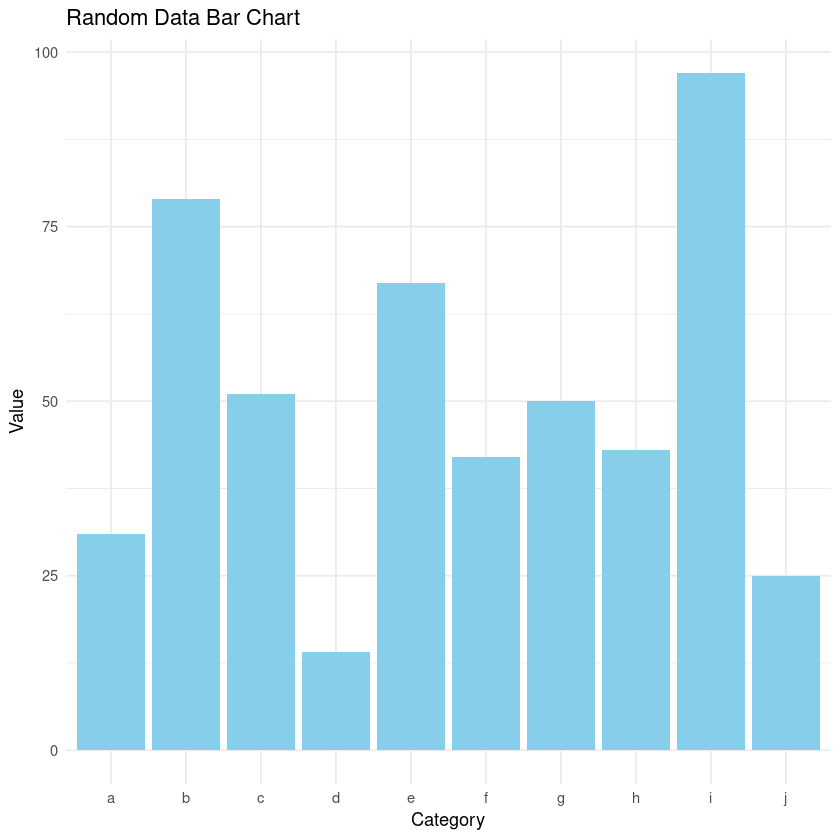

In [1]:
# Load the ggplot2 library, which helps us create plots
library(ggplot2)

# Set a seed for random number generation to make the results reproducible
set.seed(123)

# Create a data frame (a table) with two columns: 'category' and 'value'
data <- data.frame(
  category = factor(letters[1:10]),  # 'category' column with letters a to j
  value = sample(1:100, 10)  # 'value' column with 10 random numbers between 1 and 100
)

# Create a bar chart using ggplot2
ggplot(data, aes(x = category, y = value)) +  # Initialize ggplot with data and specify x and y axes
  geom_bar(stat = "identity", fill = "skyblue") +  # Create bars with skyblue color
  theme_minimal() +  # Use a minimal theme for a clean look
  labs(title = "Random Data Bar Chart", x = "Category", y = "Value")  # Add a title and labels for axes

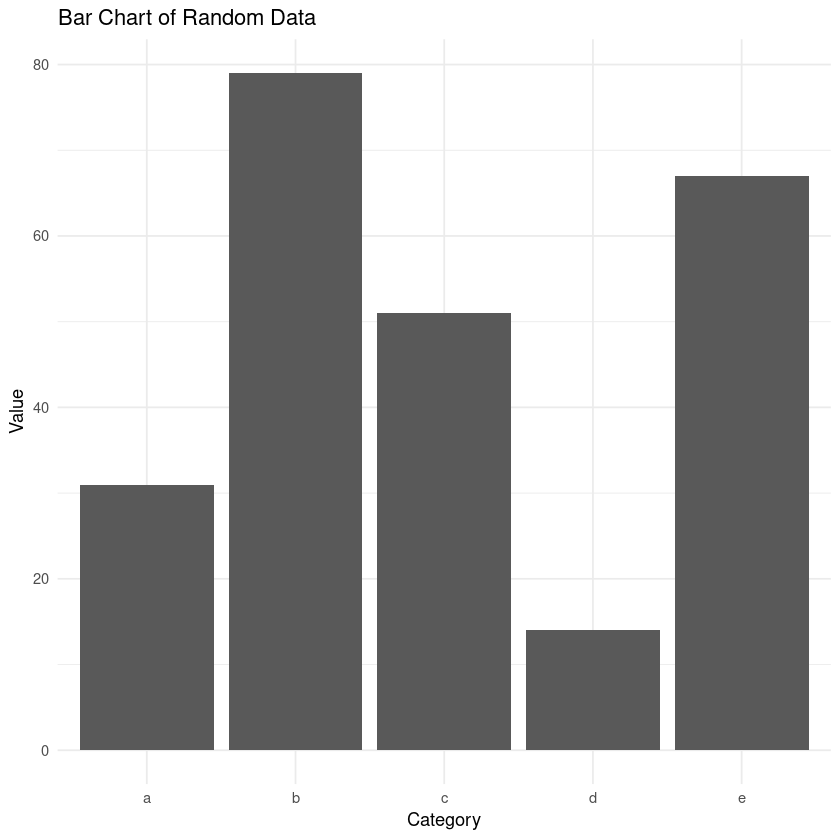

In [31]:
# code below and comments generated by asking AI assistant to generate random data and plot it in a bar chart. create a new cell and try for yourself.

# Load necessary libraries
library(ggplot2)

# Set seed for reproducibility
set.seed(123)

# Create random data
data <- data.frame(
  category = factor(letters[1:5]),
  value = sample(1:100, 5)
)

# Visualize the data
ggplot(data, aes(x = category, y = value)) +
  geom_bar(stat = "identity") +
  labs(title = "Bar Chart of Random Data", x = "Category", y = "Value") +
  theme_minimal()

## Connecting to an SQL Database.

There are two ways to connect to a database in Datalab.

### Using a database package 
In this approach, we provide the connection information as R code. We will use this approach using an R package called MySQLR later in the semester.

### Using the built in Data Manager on Datalab
In this approach, we can benefit from the AI assistant's query generation capabilities, because the Datalab engine 'knows' our data and can give us specific tables or columns matching with our request. 


We are going to connect to an SQL Database using Datalab. You will need the same connection information that you are going to use in Domo. I have provided the exact information below at the right point in the steps.

1. Select the data drop down on the extreme left of the cell window
2. Click 'Select Data Source'
3. Click 'New Data Source'
4. Select 'MySQL'
5. Enter a name for the connection. Use something relevant like dvdrental
- Hostname: [see canvas site]
- Port: 3306
- Database: dvdrental
- Username: admin
- Password: [see canvas site]
- Leave encrypt connection unchecked
- Make sure you select IS 6481-Business Analytics as the account
- Click on Connect
- Note that this is a terrible security set up. In a few weeks we will talk more about why this is so. However, for our purposes, it’s fine. The data is publicly available anyway.
- Click on Continue

6. Notice the database name shows in the leftmost side of the new cell created. You can now query that database.


In [4]:
-- Count the number of customers in the customer table
SELECT COUNT(*) AS total_customers FROM dvdrental.customer;

total_customers
<int>
599


## You can take the AI Assistant for a spin 
The AI Assistant is a sign of things to come. Take it for a spin by asking it to help you do certain things with the database. Try the following:

1. Show me the tables in this database
2. How many customers are there in this database?
3. How many payment transactions are there in this database?
4. What is the average payment for a rental?

## You can read in the SQL Table as an R dataframe in Datalab

In R, a dataframe is a structure used to store data in a tabular form—like a table or spreadsheet. It’s one of the most commonly used data structures for working with datasets because it can hold data of different types (like numbers, characters, and logical values) in each column.

A dataframe is similar to a table in a database or an Excel spreadsheet, where:

- Each row represents a single observation or record.
- Each column represents a variable or feature of the data.

WHen you read in a table from the database in R, Datalab makes the data table immediately available as an object that can be used for analysis in R. Later in this course, when we use an R package called MySQLR to connect to the database, we will see that it reads in the data directly to a dataframe, but for now we get to see this in action using this built in Datalab feature.

### Steps
1. Create a new SQL cell
2. Make sure your database dvdrental is selected
3. Ask the AI the following: "I want count of films in each categories in a table" 
4. Notice the variable name listed next to 'available as' e.g. available as df1 - that is thename of the R-dataframe

To perform this query, multiple tables had to be joined. That is an example of using SQL directly to perform ETL processing.

In [5]:
SELECT c.name AS category_name, COUNT(f.film_id) AS film_count
FROM dvdrental.category c
JOIN dvdrental.film_category fc ON c.category_id = fc.category_id
JOIN dvdrental.film f ON fc.film_id = f.film_id
GROUP BY c.name;

category_name,film_count
<chr>,<int>
Music,51
Horror,56
Drama,62
Documentary,68
Family,69
Foreign,73
Comedy,58
Sports,74
Classics,57


In [20]:
SELECT c.name AS category_name, COUNT(f.film_id) AS film_count
FROM dvdrental.category c
JOIN dvdrental.film_category fc ON c.category_id = fc.category_id
JOIN dvdrental.film f ON fc.film_id = f.film_id
GROUP BY c.name;

category_name,film_count
<chr>,<int>
Music,51
Horror,56
Drama,62
Documentary,68
Family,69
Foreign,73
Comedy,58
Sports,74
Classics,57


## We just performed a basic ETL task, joining tables and creating an extract suitable for analysis
Why is this ETL?

Extract:

The "Extract" phase involves pulling data from different sources. In this case, we have extracted  data from multiple tables.
This is usually the first step in working with data from various places like databases, spreadsheets, or APIs.

Transform:

The "Transform" phase is where you clean, format, and manipulate the data to make it more useful for analysis.
In our example, we joined multiple tables. This is a transformation step because you're combining information from two or more data sources (tables) based on a common key or relationship. The goal is to shape the data so it’s ready for analysis.
After joining, we also aggregated and reformatted the data during this phase, ensuring it's in the right structure and format for our analysis. For instance, we went from 16 rows in the 'category' table, 1000 rows in the 'film_category' bridge table, and 
1000 rows in the 'film' table, to 16 rows in the newly created 'film-category count' table.

Load:

Finally, the "Load" phase is about storing the transformed data in a format or system where it can be accessed for analysis, reporting, or visualization.
In this case, the resulting joined dataset is now in a form suitable for analysis. We are going to generat a graph from the R-dataframe object created from that step in the next step.

Note that you can do this more intentionally and transparently using Magic ETL in Domo.

## Next Steps
When you get the right table from the AI assisted prompt (it should show category_name and film_count) note the name that shows after 'available as' (it should start with df)

Edit the code below with the right variable name (mine is df1, so replace df1 with your own dataframe name below. Also make sure the names of the columns in your table are 'category_name' and 'film_count' or else the code below will not run)

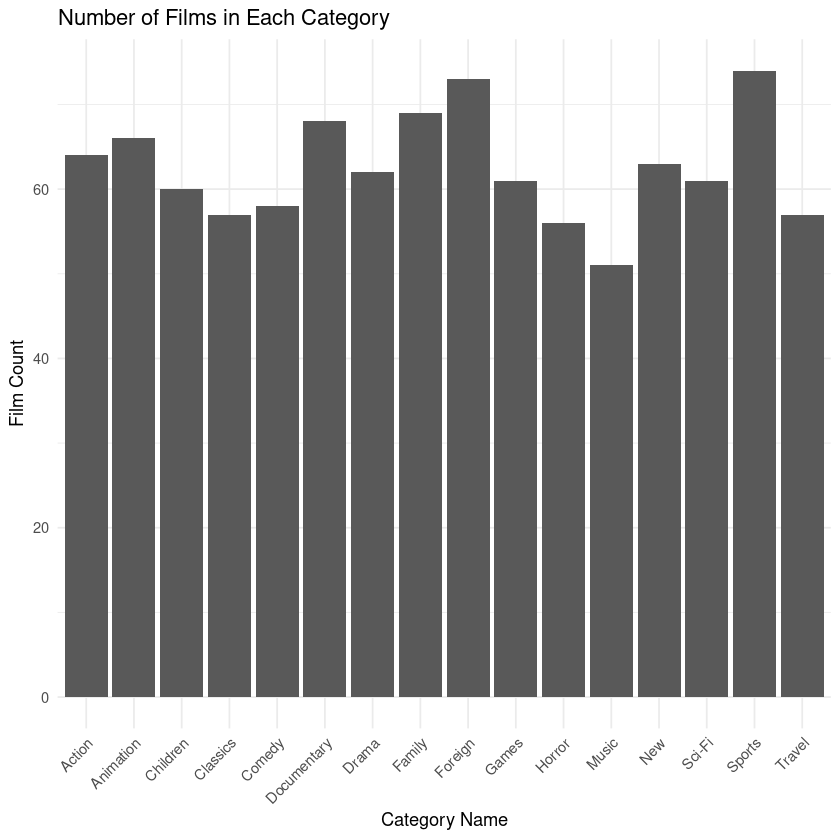

In [6]:
# Load necessary library
library(ggplot2)

# Create a bar chart using ggplot2
ggplot(df2, aes(x = category_name, y = film_count)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Number of Films in Each Category",
       x = "Category Name",
       y = "Film Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Trying out more code

Now create a new R cell below. Tell the AI assistant to create a pie chart using your dataframe (I'm using df1). That is "create a pie chart using df1"